In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.regularizers import L1
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np
import seaborn as sns

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


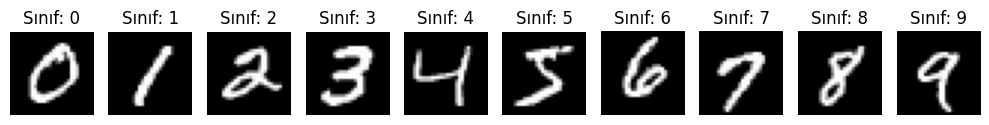

In [2]:
# 1. Veriyi yükleme ve ön işleme
(x_train, y_train), (x_test, y_test) = mnist.load_data()
num_classes = 10
indices = [None] * num_classes
for i in range(len(y_train)):
    label = y_train[i]
    if indices[label] is None:
        indices[label] = i
    if all(index is not None for index in indices):
        break

# Görselleri çizdirme
fig, axes = plt.subplots(1, num_classes, figsize=(10, 4))

for i in range(num_classes):
    if indices[i] is not None:
        image = x_train[indices[i]]
        axes[i].imshow(image, cmap='gray')
        axes[i].set_title(f"Sınıf: {i}")
        axes[i].axis('off')  # Eksenleri kapatma

plt.tight_layout()
plt.show()

x_train = x_train.reshape(60000, 784).astype('float32') / 255
x_test = x_test.reshape(10000, 784).astype('float32') / 255
y_train_categorical = to_categorical(y_train, num_classes)
y_test_categorical = to_categorical(y_test, num_classes)

In [3]:
model = Sequential([
    Dense(128, input_shape=(784,)),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    Dense(64),
    BatchNormalization(),
    Activation('relu'),
    Dropout(0.3),

    Dense(32,activation='relu', activity_regularizer=L1(0.001)),
    BatchNormalization(),
    Dense(num_classes,activation='softmax')
])

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [5]:
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

In [6]:
# 4. Modeli eğitme
batch_size = 128
epochs = 10
history = model.fit(x_train, y_train_categorical, batch_size=batch_size, epochs=epochs, validation_split=0.2,verbose=1)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.6132 - loss: 1.8535 - val_accuracy: 0.9142 - val_loss: 0.7035
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.8751 - loss: 0.6395 - val_accuracy: 0.9434 - val_loss: 0.3469
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9062 - loss: 0.4524 - val_accuracy: 0.9510 - val_loss: 0.2536
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9213 - loss: 0.3606 - val_accuracy: 0.9519 - val_loss: 0.2356
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9264 - loss: 0.3249 - val_accuracy: 0.9599 - val_loss: 0.1915
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.9347 - loss: 0.2869 - val_accuracy: 0.9599 - val_loss: 0.1874
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.9397 - loss: 0.2617 - val_accuracy: 0.9657 - val_loss: 0.1644
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.9452 - loss: 0.2373 - val_accuracy: 0.

In [7]:
#5 Modeli değerlendirme
y_pred_probalities = model.predict(x_test)
y_pred = np.argmax(y_pred_probalities, axis=1)
print(classification_report(y_test, y_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.97      0.96      0.97      1032
           3       0.97      0.95      0.96      1010
           4       0.97      0.98      0.97       982
           5       0.95      0.96      0.95       892
           6       0.94      0.99      0.96       958
           7       0.97      0.96      0.97      1028
           8       0.97      0.95      0.96       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



<Axes: >

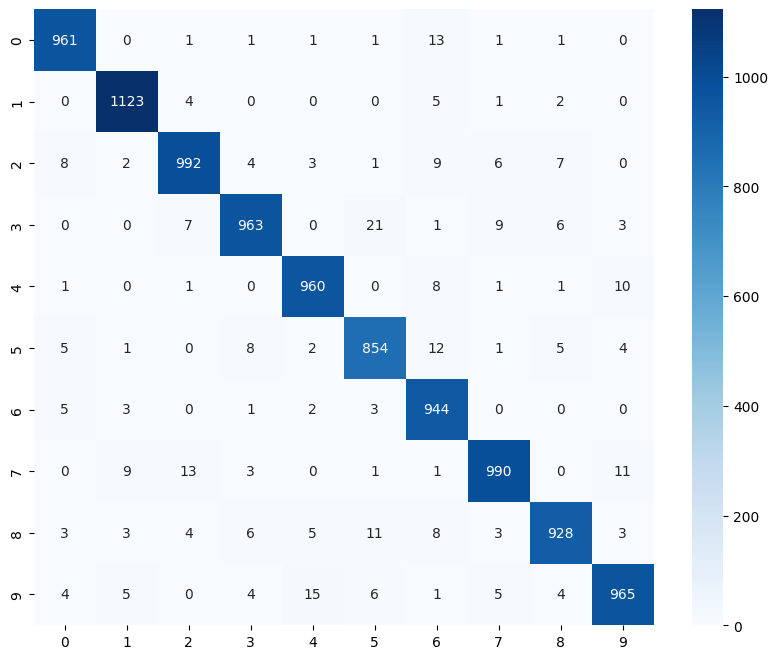

In [8]:
 # 6. Sonuçları görselleştirme
confusion_mtx = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(confusion_mtx, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))

In [9]:
#7. Confusion matrixi yazdırma
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[ 961    0    1    1    1    1   13    1    1    0]
 [   0 1123    4    0    0    0    5    1    2    0]
 [   8    2  992    4    3    1    9    6    7    0]
 [   0    0    7  963    0   21    1    9    6    3]
 [   1    0    1    0  960    0    8    1    1   10]
 [   5    1    0    8    2  854   12    1    5    4]
 [   5    3    0    1    2    3  944    0    0    0]
 [   0    9   13    3    0    1    1  990    0   11]
 [   3    3    4    6    5   11    8    3  928    3]
 [   4    5    0    4   15    6    1    5    4  965]]


In [10]:
# 8. Classfication reportu yazdırma
cr = classification_report(y_test, y_pred)
print("Classification Report:")
print(cr)

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.98      0.98       980
           1       0.98      0.99      0.98      1135
           2       0.97      0.96      0.97      1032
           3       0.97      0.95      0.96      1010
           4       0.97      0.98      0.97       982
           5       0.95      0.96      0.95       892
           6       0.94      0.99      0.96       958
           7       0.97      0.96      0.97      1028
           8       0.97      0.95      0.96       974
           9       0.97      0.96      0.96      1009

    accuracy                           0.97     10000
   macro avg       0.97      0.97      0.97     10000
weighted avg       0.97      0.97      0.97     10000



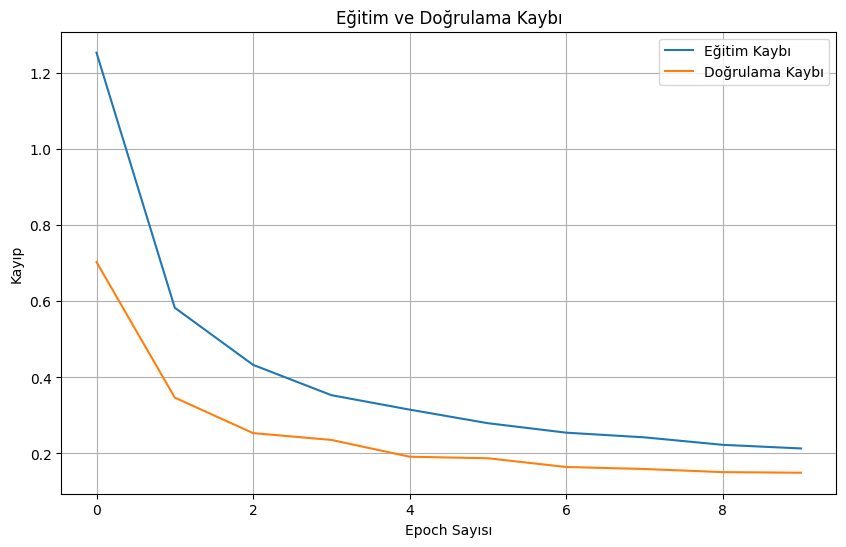

In [11]:
# 9. Loss grafiği çizdirme
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.xlabel('Epoch Sayısı')
plt.ylabel('Kayıp')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
from PIL import Image
import tkinter as tk
from tkinter import filedialog

# **ÖNEMLİ:** Model dosyasını yükleyin
model = load_model('el_yazisi_tanima_modeli.h5')

# 1. Kullanıcıdan resim dosyası seçmesini isteyin
root = tk.Tk()
root.withdraw()  # Tkinter penceresini gizle
image_path = filedialog.askopenfilename(title="Bir resim dosyası seçin", filetypes=[("Image files", "*.png;*.jpg;*.jpeg")])

if image_path:  # Eğer bir dosya seçildiyse
    try:
        # 2. Resmi yükleme ve boyutlandırma
        img = image.load_img(image_path, target_size=(28, 28), color_mode='grayscale')

        # 3. Resmi NumPy dizisine dönüştürme
        img_array = image.img_to_array(img)

        # 4. Piksel değerlerini 0-1 arasına normalleştirme
        img_array = img_array / 255.0

        # 5. Resmi modelin beklediği formata getirme
        img_array = img_array.reshape(1, 784)

        # 6. Model ile tahmin yapma
        predictions = model.predict(img_array)

        # 7. Tahmin sonuçlarını yorumlama
        predicted_class_index = np.argmax(predictions)
        confidence = predictions[0][predicted_class_index]

        print(f"Tahmin Edilen Rakam: {predicted_class_index}")
        print(f"Güven Skoru: {confidence:.4f}")

    except Exception as e:
        print(f"Bir hata oluştu: {e}")
else:
    print("Hiçbir dosya seçilmedi.")


FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = 'el_yazisi_tanima_modeli.h5', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)